# Group 7 — Exploratory Data Analysis: YelpZip
**Fake Review Detection on Yelp Using Multi-Signal Analysis**

This notebook covers:
1. Data loading & schema validation (from raw YelpZip files)
2. Class distribution (spam vs. legitimate)
3. Temporal analysis (posting patterns, burst detection)
4. Rating distribution analysis
5. Reviewer tenure & activity analysis
6. Text length & linguistic feature distributions
7. Seller concentration analysis
8. Correlation heatmap of behavioral features

---
### YelpZip File Structure (no headers, tab-separated)
| File | Columns |
|---|---|
| `metadata` | user_id, prod_id, rating, label, date |
| `reviewContent` | user_id, prod_id, date, review_text |
| `reviewGraph` | user_id, prod_id, rating |
| `userIdMapping` | original_yelp_id, numeric_id |
| `productIdMapping` | business_name, numeric_id |

**Label encoding:** `-1` = spam (fake), `+1` = legitimate (genuine)

## 0. Setup & Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Update this path to where YelpZip folder lives on your machine
DATA_DIR = Path('YelpZip-20260310T023401Z-1-001/YelpZip')
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

## 1. Data Loading & Schema Validation

In [7]:
# --- Load metadata (user_id, prod_id, rating, label, date) ---
meta = pd.read_csv(
    DATA_DIR / 'metadata',
    sep='\t',
    header=None,
    names=['user_id', 'prod_id', 'rating', 'label', 'date'],
    parse_dates=['date']
)

# --- Load review text (user_id, prod_id, date, review_text) ---
content = pd.read_csv(
    DATA_DIR / 'reviewContent',
    sep='\t',
    header=None,
    names=['user_id', 'prod_id', 'date', 'review_text'],
    parse_dates=['date']
)

# --- Load product name mapping ---
prod_map = pd.read_csv(
    DATA_DIR / 'productIdMapping',
    sep='\t',
    header=None,
    names=['business_name', 'prod_id']
)

print(f'metadata rows:      {len(meta):,}')
print(f'reviewContent rows: {len(content):,}')

# --- Merge metadata + review text on (user_id, prod_id, date) ---
# Files are NOT row-aligned (metadata=608,598 vs reviewContent=608,458 — 140 row gap).
# Left join keeps all metadata rows; unmatched ones get NaN review_text.
df = meta.merge(
    content[['user_id', 'prod_id', 'date', 'review_text']],
    on=['user_id', 'prod_id', 'date'],
    how='left'
)

# Drop duplicate rows from any many-to-many matches on the composite key
df = df.drop_duplicates(subset=['user_id', 'prod_id', 'date', 'label'])

print(f'After merge:        {len(df):,} rows  '
      f'({df["review_text"].isna().sum():,} missing review_text)')

# --- Add business name ---
df = df.merge(prod_map, on='prod_id', how='left')

# --- Binary spam flag: -1=spam → 1, +1=legit → 0 ---
df['is_spam'] = (df['label'] == -1).astype(int)

print(f'\nShape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nNull counts:\n{df.isnull().sum()}')
df.head()

metadata rows:      608,598
reviewContent rows: 608,458
After merge:        608,598 rows  (140 missing review_text)

Shape: (608598, 8)
Columns: ['user_id', 'prod_id', 'rating', 'label', 'date', 'review_text', 'business_name', 'is_spam']

Null counts:
user_id            0
prod_id            0
rating             0
label              0
date               0
review_text      140
business_name      0
is_spam            0
dtype: int64


,user_id,prod_id,rating,label,date,review_text,business_name,is_spam
0,5044,0,1.0,-1,2014-11-16,"Drinks were bad, the hot chocolate was watered...",Toast,1
1,5045,0,1.0,-1,2014-09-08,This was the worst experience I've ever had a ...,Toast,1
2,5046,0,3.0,-1,2013-10-06,This is located on the site of the old Spruce ...,Toast,1
3,5047,0,5.0,-1,2014-11-30,I enjoyed coffee and breakfast twice at Toast ...,Toast,1
4,5048,0,5.0,-1,2014-08-28,I love Toast! The food choices are fantastic -...,Toast,1


In [8]:
print(f'Total reviews:    {len(df):,}')
print(f'Unique reviewers: {df["user_id"].nunique():,}')
print(f'Unique products:  {df["prod_id"].nunique():,}')
print(f'Unique businesses:{df["business_name"].nunique():,}')
print(f'Date range:       {df["date"].min().date()} → {df["date"].max().date()}')
print(f'\nRating values:    {sorted(df["rating"].unique())}')
print(f'Label values:     {sorted(df["label"].unique())}  (-1=spam, +1=legit)')

Total reviews:    608,598
Unique reviewers: 260,277
Unique products:  5,044
Unique businesses:5,044
Date range:       2004-10-20 → 2015-01-10

Rating values:    [1.0, 2.0, 3.0, 4.0, 5.0]
Label values:     [-1, 1]  (-1=spam, +1=legit)


## 2. Class Distribution (Spam vs. Legitimate)

Legitimate (+1): 528,132  (86.8%)
Spam       (-1): 80,466  (13.2%)


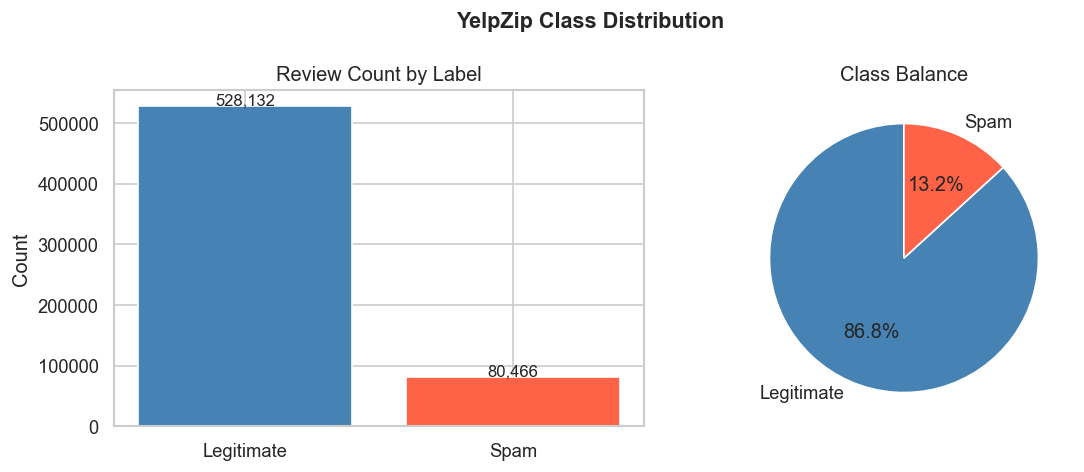

In [9]:
spam_count = df['is_spam'].sum()
legit_count = len(df) - spam_count
spam_pct = spam_count / len(df) * 100

print(f'Legitimate (+1): {legit_count:,}  ({100-spam_pct:.1f}%)')
print(f'Spam       (-1): {spam_count:,}  ({spam_pct:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Legitimate', 'Spam'], [legit_count, spam_count],
            color=['steelblue', 'tomato'])
axes[0].set_title('Review Count by Label')
axes[0].set_ylabel('Count')
for i, v in enumerate([legit_count, spam_count]):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontsize=10)

axes[1].pie([legit_count, spam_count], labels=['Legitimate', 'Spam'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Class Balance')

plt.suptitle('YelpZip Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_class_distribution.png', bbox_inches='tight')
plt.show()

## 3. Temporal Analysis

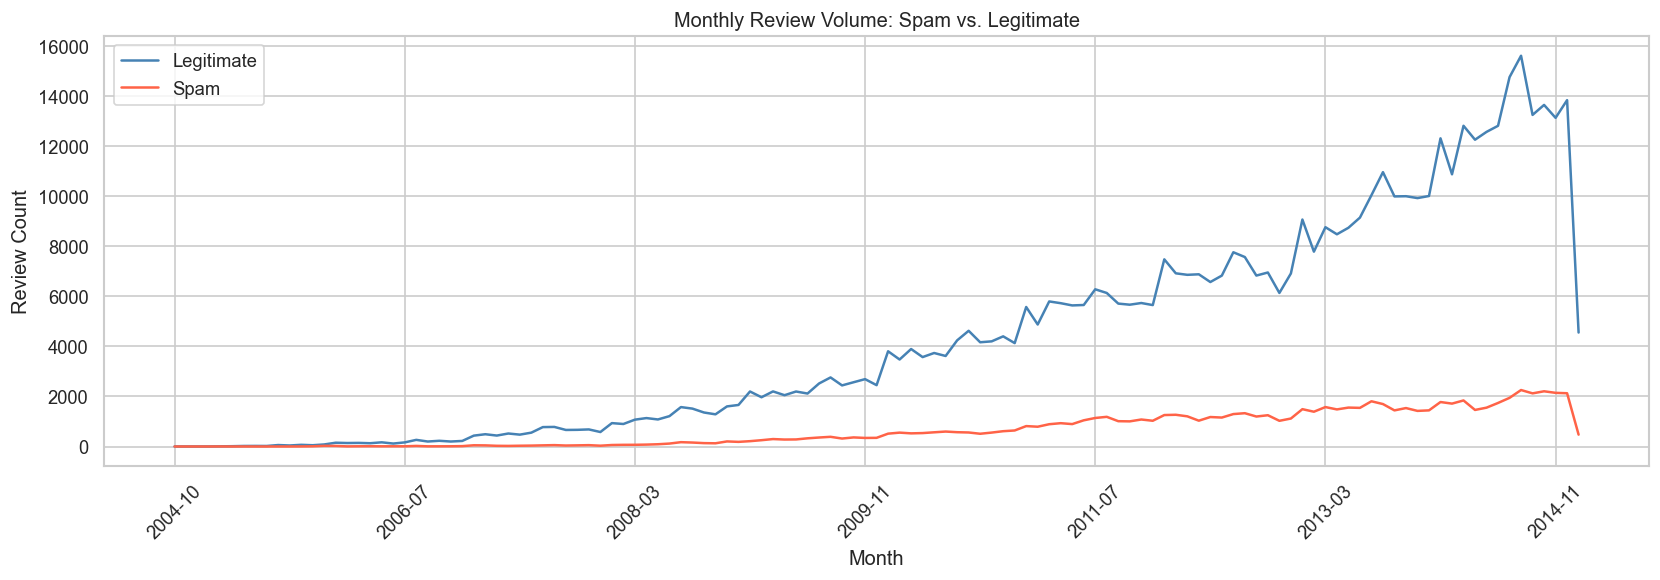

In [10]:
df['year_month'] = df['date'].dt.to_period('M')
df['week'] = df['date'].dt.to_period('W')
df['day_of_week'] = df['date'].dt.day_name()

# Monthly volume: legit vs spam
monthly = df.groupby(['year_month', 'is_spam']).size().unstack(fill_value=0)
monthly.columns = ['Legitimate', 'Spam']
monthly.index = monthly.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
monthly.plot(kind='line', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Monthly Review Volume: Spam vs. Legitimate')
ax.set_xlabel('Month')
ax.set_ylabel('Review Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_temporal_monthly.png', bbox_inches='tight')
plt.show()

In [11]:
# Temporal burst: reviewers posting 3+ reviews in a single week
weekly_counts = df.groupby(['user_id', 'week']).size().reset_index(name='reviews_that_week')
burst_threshold = 3
burst_users = weekly_counts[
    weekly_counts['reviews_that_week'] >= burst_threshold
]['user_id'].unique()

df['is_burst_reviewer'] = df['user_id'].isin(burst_users).astype(int)

burst_spam_rate  = df[df['is_burst_reviewer'] == 1]['is_spam'].mean()
normal_spam_rate = df[df['is_burst_reviewer'] == 0]['is_spam'].mean()

print(f'Burst reviewers (≥{burst_threshold} reviews/week):  {len(burst_users):,}')
print(f'Spam rate — burst reviewers:   {burst_spam_rate:.1%}')
print(f'Spam rate — normal reviewers:  {normal_spam_rate:.1%}')

Burst reviewers (≥3 reviews/week):  16,454
Spam rate — burst reviewers:   5.5%
Spam rate — normal reviewers:  16.5%


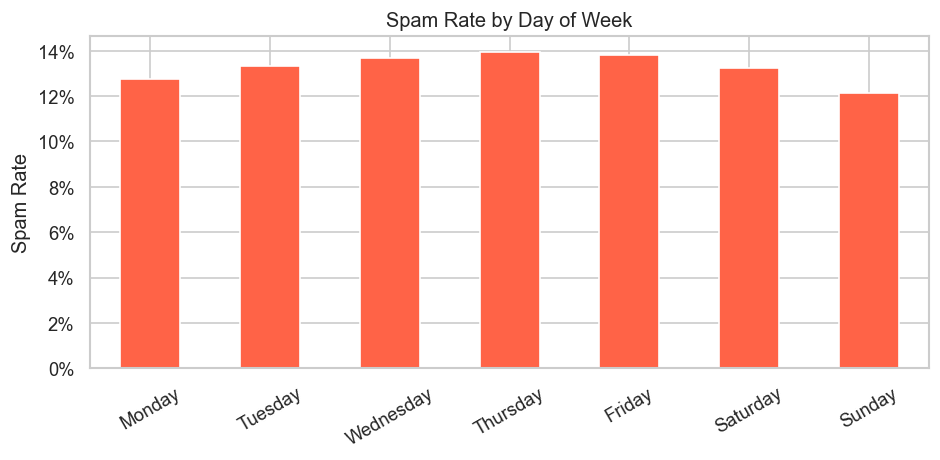

In [12]:
# Day-of-week spam pattern
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_spam = df.groupby('day_of_week')['is_spam'].mean().reindex(dow_order)

fig, ax = plt.subplots(figsize=(8, 4))
dow_spam.plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
ax.set_title('Spam Rate by Day of Week')
ax.set_xlabel('')
ax.set_ylabel('Spam Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_dow_spam.png', bbox_inches='tight')
plt.show()

## 4. Rating Distribution

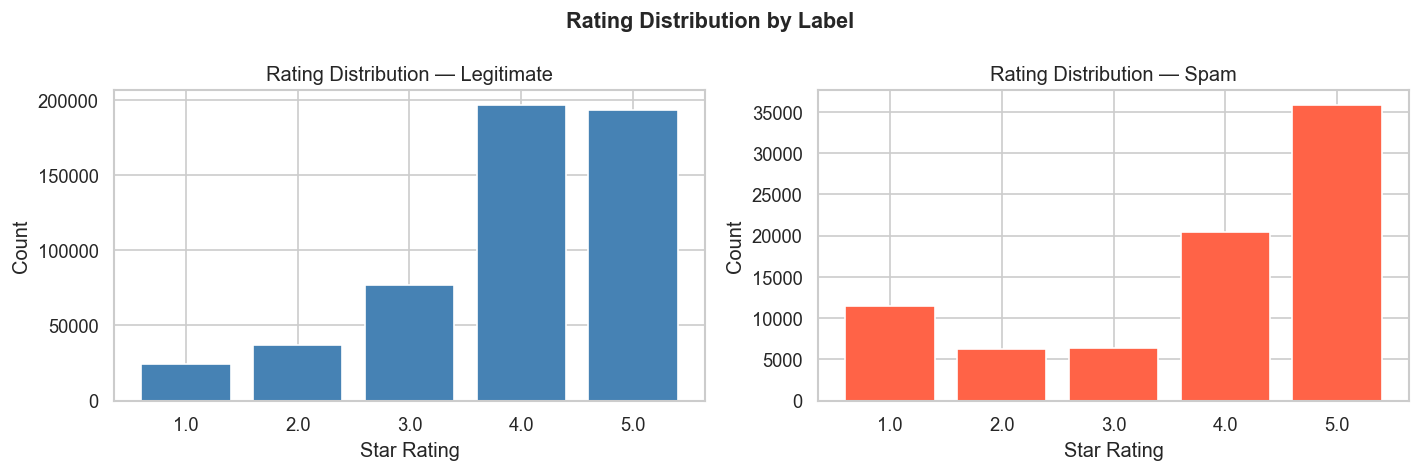

Spam rate by star rating:
rating
1.0    0.323567
2.0    0.145237
3.0    0.076270
4.0    0.094213
5.0    0.156380


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, (spam_val, label_name) in enumerate([(0, 'Legitimate'), (1, 'Spam')]):
    subset = df[df['is_spam'] == spam_val]['rating'].value_counts().sort_index()
    axes[i].bar(subset.index.astype(str), subset.values,
                color='steelblue' if spam_val == 0 else 'tomato')
    axes[i].set_title(f'Rating Distribution — {label_name}')
    axes[i].set_xlabel('Star Rating')
    axes[i].set_ylabel('Count')

plt.suptitle('Rating Distribution by Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_rating_distribution.png', bbox_inches='tight')
plt.show()

# Spam rate per star rating
spam_by_rating = df.groupby('rating')['is_spam'].mean().rename('spam_rate')
print('Spam rate by star rating:')
print(spam_by_rating.to_string())

## 5. Reviewer Tenure & Activity

In [14]:
reviewer_activity = df.groupby('user_id').agg(
    total_reviews=('prod_id', 'count'),
    spam_count=('is_spam', 'sum'),
    first_review=('date', 'min'),
    last_review=('date', 'max')
).reset_index()

reviewer_activity['spam_rate']    = reviewer_activity['spam_count'] / reviewer_activity['total_reviews']
reviewer_activity['tenure_days']  = (reviewer_activity['last_review'] - reviewer_activity['first_review']).dt.days
reviewer_activity['is_spammer']   = (reviewer_activity['spam_rate'] > 0.5).astype(int)

print('Reviewer activity summary:')
print(reviewer_activity[['total_reviews', 'tenure_days', 'spam_rate']].describe().round(3))

Reviewer activity summary:
       total_reviews  tenure_days   spam_rate
count     260277.000   260277.000  260277.000
mean           2.338      139.669       0.234
std            4.496      358.397       0.421
min            1.000        0.000       0.000
25%            1.000        0.000       0.000
50%            1.000        0.000       0.000
75%            2.000       15.000       0.000
max          197.000     3508.000       1.000


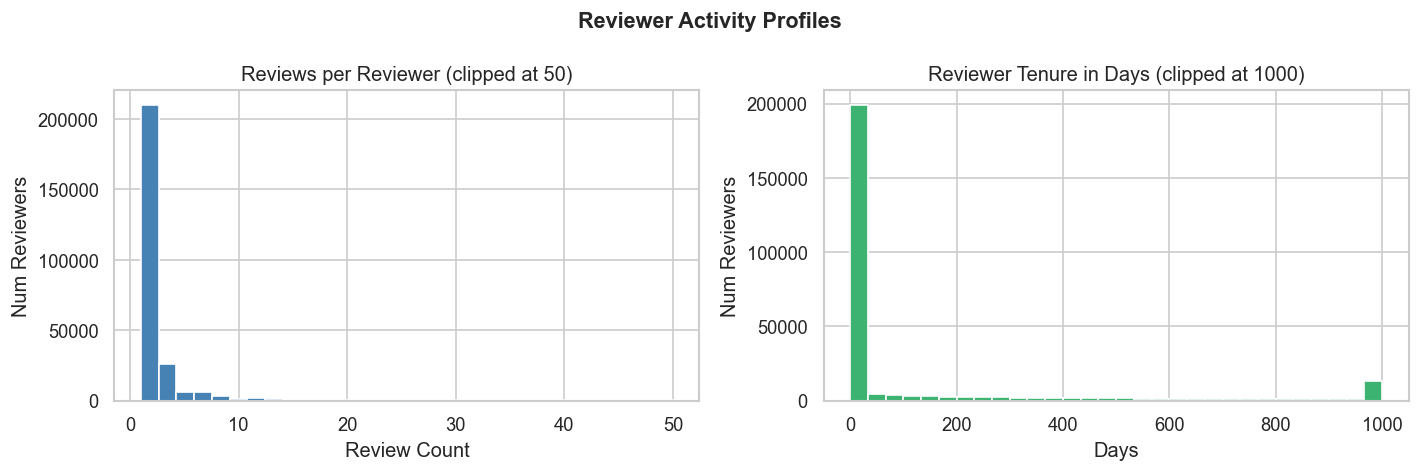


Tenure (days) by reviewer type:
               count   mean    std  min  25%  50%    75%     max
is_spammer                                                      
0           200082.0  176.2  396.9  0.0  0.0  0.0  104.0  3508.0
1            60195.0   18.3  111.8  0.0  0.0  0.0    0.0  2639.0


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(reviewer_activity['total_reviews'].clip(upper=50),
             bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Reviews per Reviewer (clipped at 50)')
axes[0].set_xlabel('Review Count')
axes[0].set_ylabel('Num Reviewers')

axes[1].hist(reviewer_activity['tenure_days'].dropna().clip(upper=1000),
             bins=30, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Reviewer Tenure in Days (clipped at 1000)')
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Num Reviewers')

plt.suptitle('Reviewer Activity Profiles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_reviewer_activity.png', bbox_inches='tight')
plt.show()

# Spammer vs legit reviewer tenure
print('\nTenure (days) by reviewer type:')
print(reviewer_activity.groupby('is_spammer')['tenure_days'].describe().round(1))

## 6. Text Length & Linguistic Features

In [16]:
df['review_length']    = df['review_text'].str.split().str.len()
df['char_count']       = df['review_text'].str.len()
df['exclamation_count']= df['review_text'].str.count('!')
df['caps_ratio']       = df['review_text'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
)

print('Text feature means by label (-1=spam, +1=legit):')
print(df.groupby('label')[['review_length', 'char_count', 'exclamation_count', 'caps_ratio']]
      .mean().round(3))

Text feature means by label (-1=spam, +1=legit):
       review_length  char_count  exclamation_count  caps_ratio
label                                                          
-1            87.132     474.179              1.231       0.031
 1           119.615     652.737              1.179       0.029


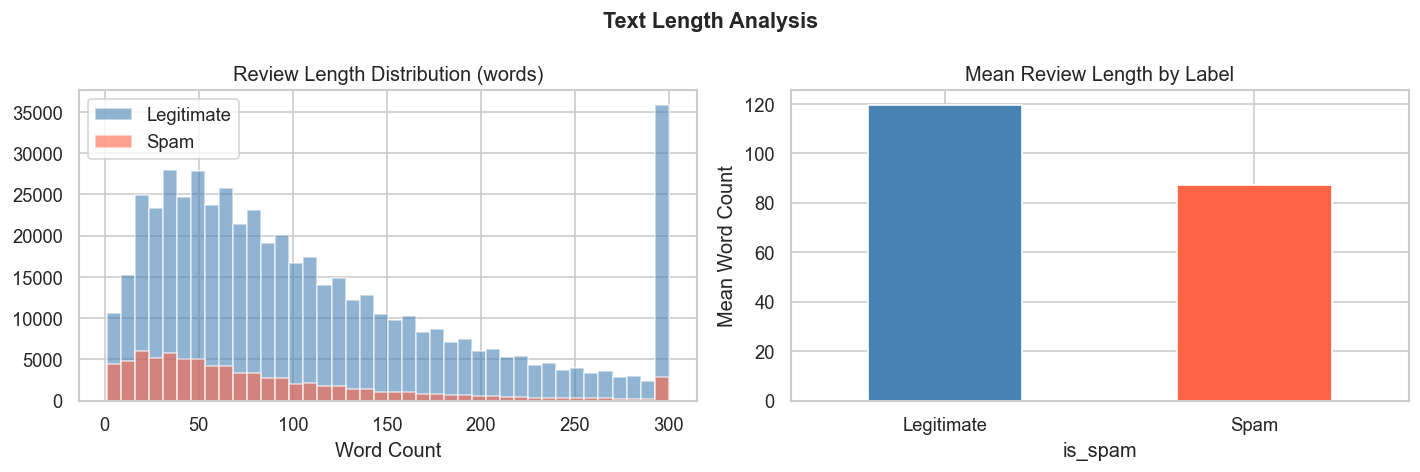

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for spam_val, label_name, color in [(0, 'Legitimate', 'steelblue'), (1, 'Spam', 'tomato')]:
    subset = df[df['is_spam'] == spam_val]['review_length'].clip(upper=300)
    axes[0].hist(subset, bins=40, alpha=0.6, label=label_name, color=color)

axes[0].set_title('Review Length Distribution (words)')
axes[0].set_xlabel('Word Count')
axes[0].legend()

df.groupby('is_spam')['review_length'].mean().rename({0: 'Legitimate', 1: 'Spam'}).plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato']
)
axes[1].set_title('Mean Review Length by Label')
axes[1].set_xticklabels(['Legitimate', 'Spam'], rotation=0)
axes[1].set_ylabel('Mean Word Count')

plt.suptitle('Text Length Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_text_length.png', bbox_inches='tight')
plt.show()

## 7. Seller Concentration Analysis

In [18]:
# For each reviewer: what fraction of their reviews go to a single seller?
reviewer_seller      = df.groupby(['user_id', 'prod_id']).size().reset_index(name='count')
reviewer_total       = df.groupby('user_id').size().reset_index(name='total')
reviewer_max_seller  = reviewer_seller.groupby('user_id')['count'].max().reset_index(name='max_single_seller')

seller_conc = reviewer_total.merge(reviewer_max_seller, on='user_id')
seller_conc['concentration'] = seller_conc['max_single_seller'] / seller_conc['total']
seller_conc = seller_conc.merge(reviewer_activity[['user_id', 'is_spammer']], on='user_id')

print('Seller concentration by reviewer type (0=legit, 1=spammer):')
print(seller_conc.groupby('is_spammer')['concentration'].describe().round(3))

Seller concentration by reviewer type (0=legit, 1=spammer):
               count   mean    std    min  25%  50%  75%  max
is_spammer                                                   
0           200082.0  0.733  0.341  0.005  0.5  1.0  1.0  1.0
1            60195.0  0.908  0.219  0.021  1.0  1.0  1.0  1.0


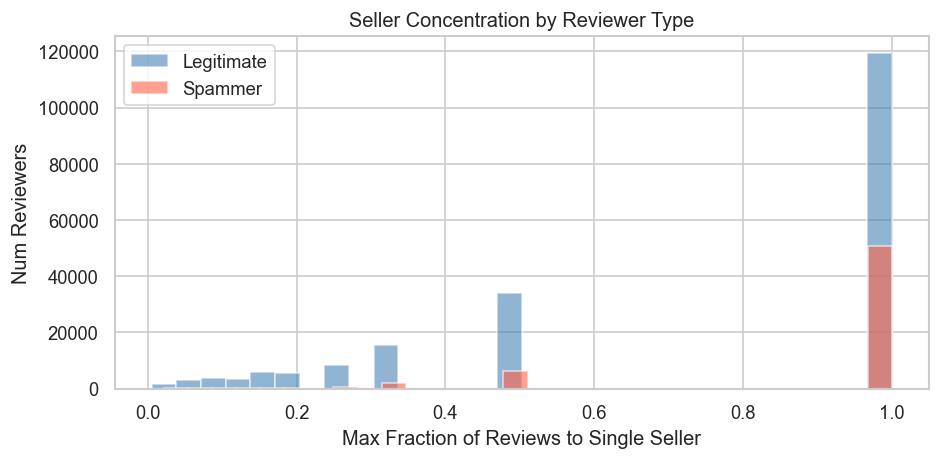

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
for spam_val, label_name, color in [(0, 'Legitimate', 'steelblue'), (1, 'Spammer', 'tomato')]:
    subset = seller_conc[seller_conc['is_spammer'] == spam_val]['concentration']
    ax.hist(subset, bins=30, alpha=0.6, label=label_name, color=color)

ax.set_title('Seller Concentration by Reviewer Type')
ax.set_xlabel('Max Fraction of Reviews to Single Seller')
ax.set_ylabel('Num Reviewers')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_seller_concentration.png', bbox_inches='tight')
plt.show()

## 8. Behavioral Feature Correlation Heatmap

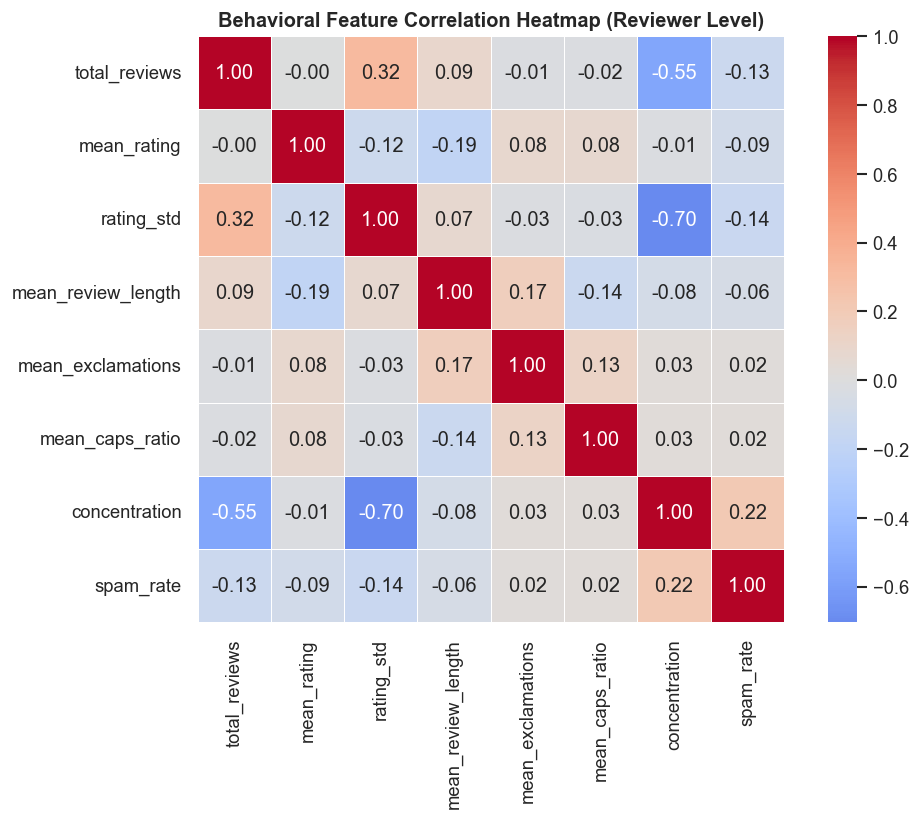

In [20]:
reviewer_features = (
    df.groupby('user_id')
    .agg(
        total_reviews     =('prod_id',           'count'),
        mean_rating       =('rating',            'mean'),
        rating_std        =('rating',            'std'),
        mean_review_length=('review_length',     'mean'),
        mean_exclamations =('exclamation_count', 'mean'),
        mean_caps_ratio   =('caps_ratio',        'mean'),
        spam_rate         =('is_spam',           'mean')
    )
    .fillna(0)
    .reset_index()
)
reviewer_features = reviewer_features.merge(
    seller_conc[['user_id', 'concentration']], on='user_id', how='left'
)

feature_cols = ['total_reviews', 'mean_rating', 'rating_std', 'mean_review_length',
                'mean_exclamations', 'mean_caps_ratio', 'concentration', 'spam_rate']

corr_matrix = reviewer_features[feature_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Behavioral Feature Correlation Heatmap (Reviewer Level)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 9. EDA Summary

| Finding | Detail |
|---|---|
| Total reviews | 608,598 |
| Class imbalance | ~13.2% spam (-1), ~86.8% legitimate (+1) |
| Rating extremes | Check if spam over-indexed at 1★ and 5★ |
| Burst behavior | Burst reviewers (≥3/week) expected to show higher spam rates |
| Review length | Spam reviews tend to be shorter on average |
| Seller concentration | Spammers concentrate reviews on fewer sellers |
| Caps / exclamations | Spam reviews may use more emphasis markers |

These findings motivate the multi-signal pipeline design — no single feature cleanly separates spam from legitimate reviews.

In [21]:
# Save reviewer feature matrix for downstream pipeline layers
reviewer_features.to_csv('reviewer_features.csv', index=False)
print(f'Saved reviewer_features.csv: {reviewer_features.shape}')
reviewer_features.head()

Saved reviewer_features.csv: (260277, 9)


,user_id,total_reviews,mean_rating,rating_std,mean_review_length,mean_exclamations,mean_caps_ratio,spam_rate,concentration
0,5044,1,1.00,0.0,36.00,0.0,0.010695,1.0,1.00
1,5045,1,1.00,0.0,248.00,0.0,0.017455,1.0,1.00
2,5046,4,3.25,0.5,45.25,0.0,0.030664,1.0,0.25
3,5047,1,5.00,0.0,233.00,2.0,0.025038,1.0,1.00
4,5048,1,5.00,0.0,152.00,2.0,0.022277,1.0,1.00
